## 1. Import Necessary Libraries

In [35]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


## 2. Import Dataset

In [2]:
cars_data = pd.read_csv("Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3.Data Understanding

### i) Perform Initial investigation on the Data

In [3]:
cars_data.shape

(81, 5)

In [4]:
cars_data.isnull().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [5]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [6]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## 3. Now let's check for the assumptions

### Test 1: Linearity Test

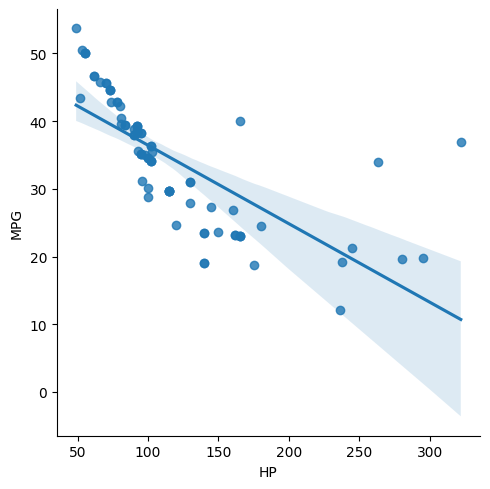

In [7]:
sns.lmplot(cars_data, x = "HP", y = "MPG")

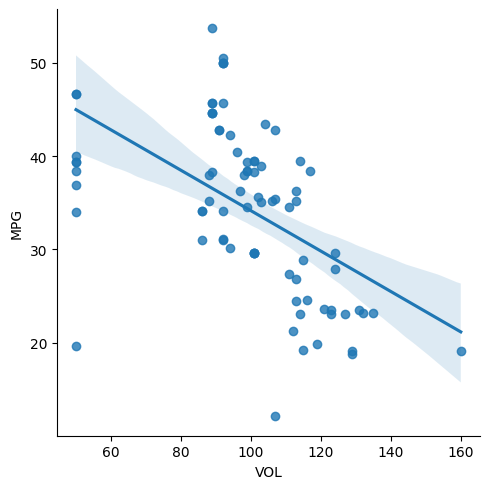

In [8]:
sns.lmplot(cars_data, x = "VOL", y = "MPG")

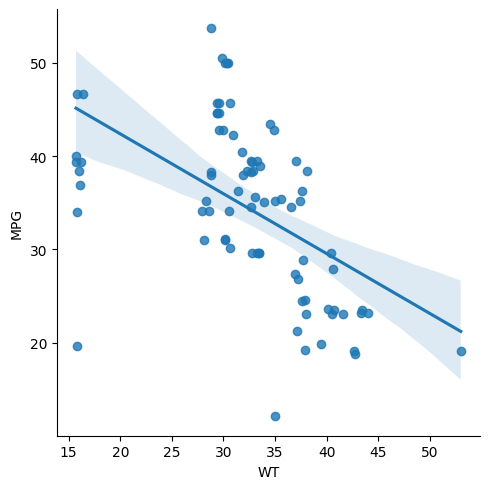

In [9]:
sns.lmplot(cars_data, x = "WT", y = "MPG")

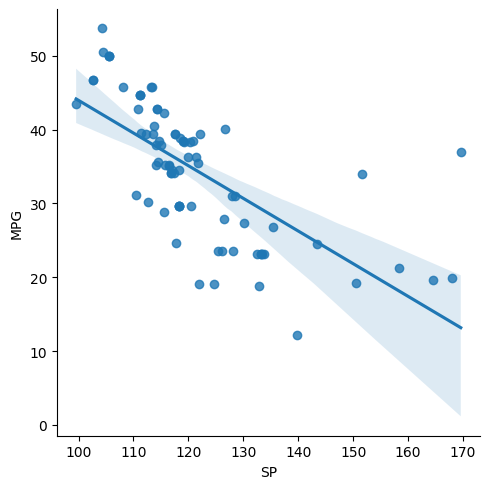

In [10]:
sns.lmplot(cars_data, x = "SP", y = "MPG")

### Test 1: Linearity failed

## Test 2: Normality Test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

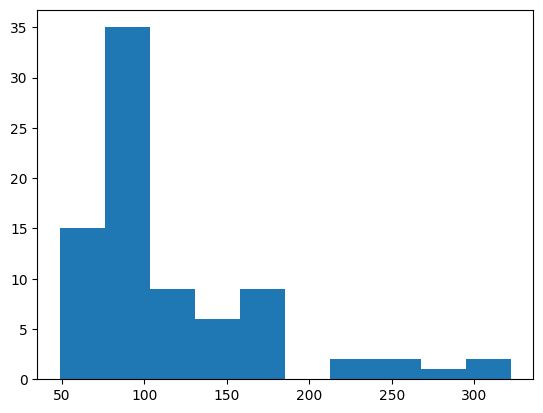

In [11]:
plt.hist(cars_data["HP"])

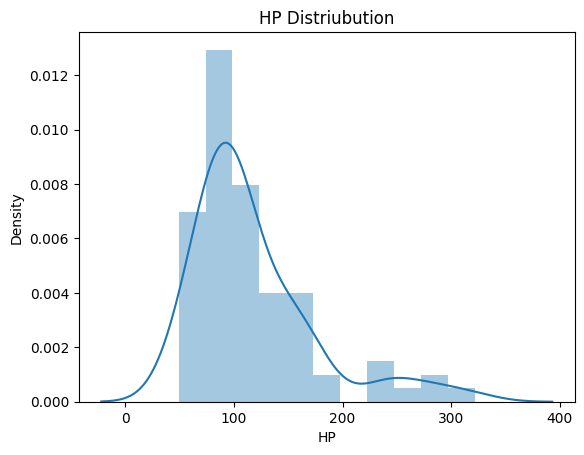

In [36]:
sns.distplot(cars_data["HP"])
plt.title("HP Distriubution")
plt.show()

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

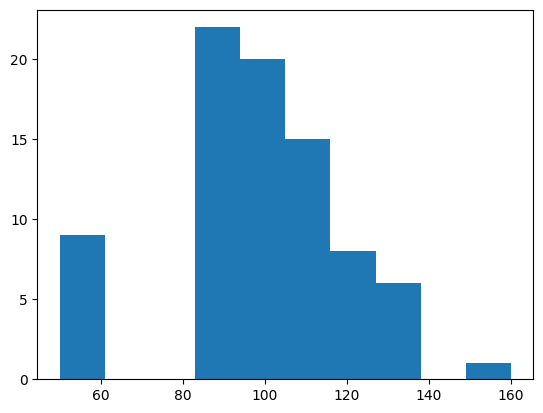

In [13]:
plt.hist(cars_data["VOL"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

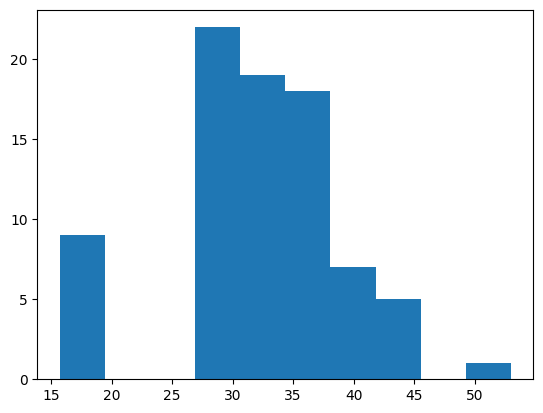

In [14]:
plt.hist(cars_data["WT"])

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

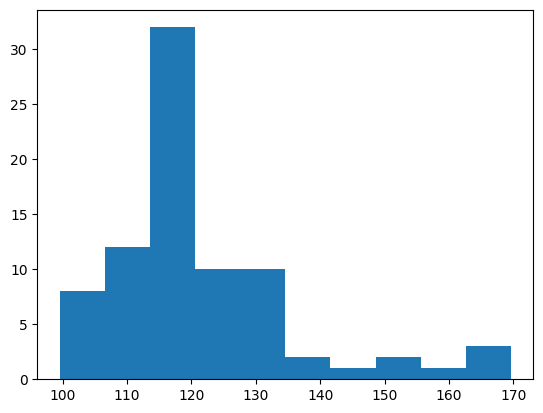

In [15]:
plt.hist(cars_data["SP"])

### Test 2: Normality also failed

## Test 3 - Multicolinearity Test

In [16]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


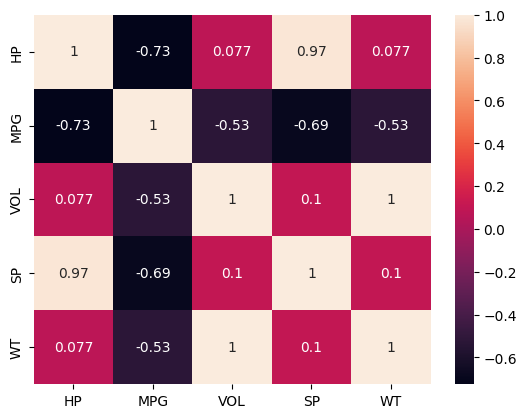

In [17]:
sns.heatmap(corr_matrix, annot = True)
plt.show()

### Test 3 - There is Multicollinearity in the Data

### Test 4 - AutoRegression Passed
Auto Regression test means that there is no Time related series in this data.

## 4. Data Preparation

In [18]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [19]:
x = cars_data[["HP","VOL","SP","WT"]]
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [20]:
y = cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

### There is nothing to prepare because all features are numeric.

In [21]:
linear_model = LinearRegression()

## 6. Model Training

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x,y,train_size = 0.80,shuffle = True,random_state = 13)
X_train, X_test, y_train, y_test

(     HP  VOL          SP         WT
 23   81   96  113.829145  31.837122
 31   84  101  112.288996  33.234361
 55  130  124  126.404312  40.589068
 61  120  116  117.668550  37.860411
 33  102  113  121.392639  37.573290
 ..  ...  ...         ...        ...
 58  100   94  112.645204  30.615283
 25   92   50  114.598513  16.043175
 16   78   91  114.369293  29.535784
 74  140  129  121.864163  42.618698
 48  130   86  127.909442  28.070597
 
 [64 rows x 4 columns],
      HP  VOL          SP         WT
 56   96   92  110.461264  30.147543
 37  102   86  116.909442  27.879915
 41   95  106  115.748847  35.027176
 27   92   99  119.105055  32.835069
 75  175  129  132.864163  42.778219
 78  263   50  151.598513  15.769625
 44   93  102  114.380966  33.078632
 29  103  107  121.840817  35.549360
 76  322   50  169.598513  16.132947
 63  140  123  125.312342  40.722831
 14   66   89  108.185353  29.347279
 4    53   92  104.461264  29.889149
 60  145  111  130.208698  36.888153
 47   98  10

In [24]:
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.24,-0.44, 0.43, 0.89]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','VOL','SP','WT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,24.65
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [25]:
linear_model.intercept_

np.float64(24.64504696823717)

In [26]:
linear_model.coef_    # its the Slope and four values are HP,VOL,SP,WT 

array([-0.24361077, -0.43907501,  0.43263503,  0.88763291])

In [27]:
y_predicted_train = linear_model.predict(X_train)
y_predicted_train

array([40.26752657, 37.91523227, 29.24547174, 28.9927371 , 36.0512687 ,
       46.49635517, 45.53077668, 19.73643178, 43.47478167, 38.98587215,
       41.36104716, 41.96373018, 14.9785635 , 37.38326263, 33.15803602,
       44.23482665, 33.13872081, 33.22362689, 36.10461746, 38.96526743,
       37.31685352, 11.69345563, 41.95033147,  8.1818399 , 38.02879361,
       32.5154312 , 42.16441535, 43.38059454, 21.28626886, 46.04213082,
       36.43557917, 32.94099417, 23.42391883, 26.06880729, 43.74919307,
       37.77486826, 34.8890387 , 26.60967741, 22.69291456, 37.74057205,
       38.20082109, 40.71777886, 35.4329158 , 31.21372069, 39.99718218,
       39.53571539, 41.73405839, 43.52115424, 45.13969728, 24.0429492 ,
       38.57612148, 38.50166332, 36.94250444, 43.27862061, 30.1343697 ,
       27.69567023, 35.08524159, 25.42446041, 36.89212579, 34.92031326,
       44.09888641, 41.38467713, 24.45132804, 35.46968637])

## 7. Model Testing

In [37]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_predicted_test)
print(r2)

0.13752273300741769


In [38]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_predicted_test)
print(mae)

4.608137851840664


In [39]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_predicted_test)
print(mse)

59.8221666799562


In [40]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_predicted_test))
print(rmse)

7.734479082650376


In [30]:
y_predicted_test = linear_model.predict(X_test)
y_predicted_test

array([35.41287569, 37.36254791, 36.12835246, 39.43893746, 20.82553168,
       18.20612888, 36.05048907, 36.83949897, 11.94302041, 26.89474664,
       42.34344427, 43.06296912, 29.66014193, 36.03641945, 23.30491933,
       17.23864616, 26.05506754])

In [44]:
y_pred = linear_model.predict(x)
y_pred

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

## 8. Model Evaluation

In [33]:
error = y_test - y_predicted_test
error

56    -4.299292
37    -3.291880
41    -0.975625
27    -1.027934
75    -2.062695
78    15.793871
44    -0.406931
29    -1.435307
76    24.956980
63    -3.378830
14     3.391449
4      7.441263
60    -2.305877
47    -0.984090
72    -0.101350
69     4.035062
64    -2.449909
Name: MPG, dtype: float64

In [57]:
cars_data["error"] = error
cars_data

,HP,MPG,VOL,SP,WT,error
0,49,53.700681,89,104.185353,28.762059,10.258747
1,55,50.013401,92,105.461264,30.466833,7.624608
2,55,50.013401,92,105.461264,30.193597,7.734060
3,70,45.696322,92,113.461264,30.632114,3.157963
4,53,50.504232,92,104.461264,29.889149,8.331584
...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,15.617904
77,238,19.197888,115,150.576579,37.923113,1.298838
78,263,34.000000,50,151.598513,15.769625,7.863547
79,295,19.833733,119,167.944460,39.423099,7.517122


In [59]:
del cars_data["error"]

### Let's now perform Test 5: Homoscedasticity Test

ValueError: x and y must be the same size

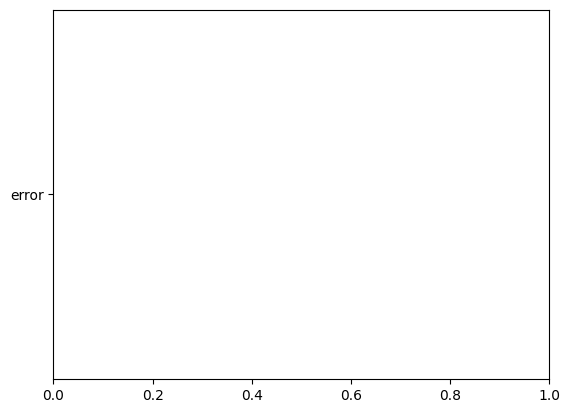

In [56]:
plt.scatter(data=cars_data, x = "HP", y = "error")

<Axes: xlabel='HP', ylabel='MPG'>

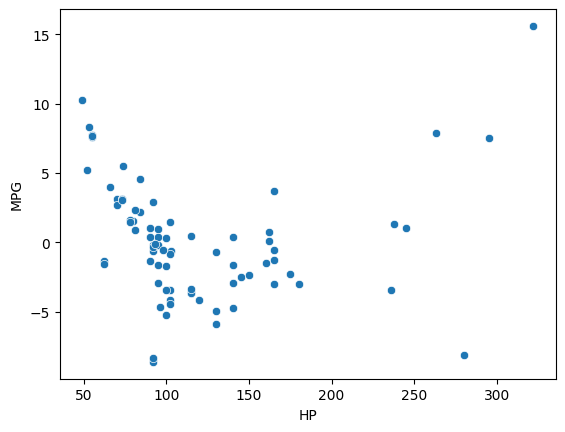

In [60]:
sns.scatterplot(data=cars_data, x = "HP", y = error)

<Axes: xlabel='SP', ylabel='MPG'>

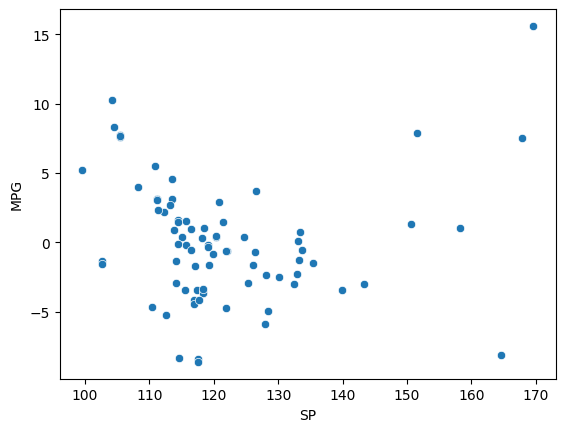

In [61]:
sns.scatterplot(data=cars_data, x = "SP", y = error)

<Axes: xlabel='WT', ylabel='MPG'>

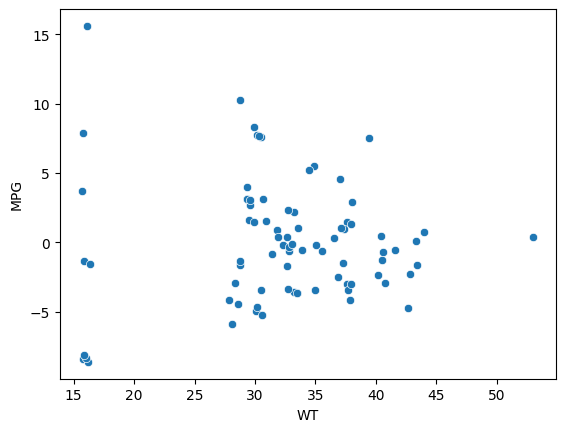

In [62]:
sns.scatterplot(data=cars_data, x = "WT", y = error)

<Axes: xlabel='VOL', ylabel='MPG'>

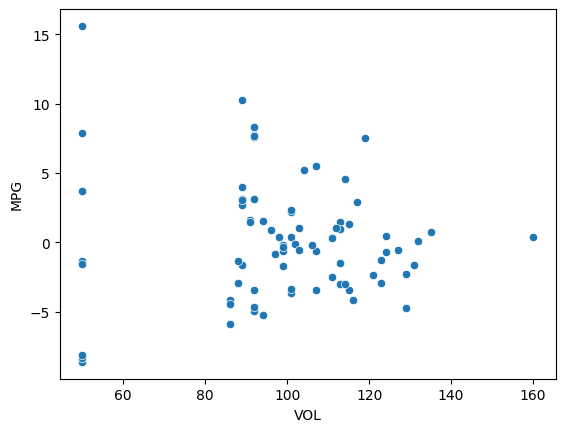

In [63]:
sns.scatterplot(data=cars_data, x = "VOL", y = error)

### Test 5 Homoscedasticity Test also Failed

## Test 6: Zero Residual Mean Test

<Axes: xlabel='MPG'>

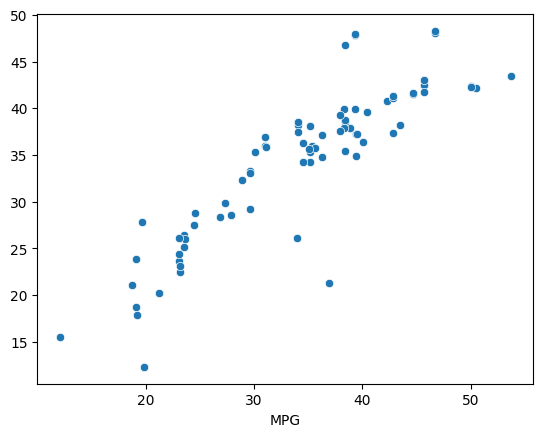

In [64]:
sns.scatterplot(x = cars_data["MPG"], y = y_pred)

### Test 6: Zero Residual Mean Test is also Failed

## 9. Model Deployment

In [65]:
from pickle import dump

In [69]:
dump(obj = linear_model, file = open(file = "linear_intelligence_file.pkl", mode = "wb"))

In [70]:
from pickle import load

In [72]:
linear_intel_pkl = load(file = open(file = "linear_intelligence_file.pkl", mode = "rb"))
linear_intel_pkl

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.21,-0.34, 0.4 , 0.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','VOL','SP','WT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.68
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [73]:
linear_intel_pkl.predict(x)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

## THE END!!